In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN


In [ ]:
# Load Dataset
dataset = pd.read_csv("GOOGL.csv")
dataset

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,2.502503,2.604104,2.401401,2.511011,2.511011,893181924
1,2004-08-20,2.527778,2.729730,2.515015,2.710460,2.710460,456686856
2,2004-08-23,2.771522,2.839840,2.728979,2.737738,2.737738,365122512
3,2004-08-24,2.783784,2.792793,2.591842,2.624374,2.624374,304946748
4,2004-08-25,2.626627,2.702703,2.599600,2.652653,2.652653,183772044
...,...,...,...,...,...,...,...
4966,2024-05-13,164.259995,169.279999,164.000000,169.139999,169.139999,31327600
4967,2024-05-14,169.770004,171.250000,168.800003,170.339996,170.339996,25127100
4968,2024-05-15,170.630005,172.649994,170.509995,172.509995,172.509995,26948400
4969,2024-05-16,173.289993,175.119995,172.690002,174.179993,174.179993,27867900


In [ ]:
# Use only 'Close' price
data = dataset['Close'].values


In [ ]:
# Reshape into 2D array
data = data.reshape(-1,1)

In [ ]:
# Feature Scaling
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [ ]:
# Create Training Data
X = []
y = []

# Use previous 60 days to predict next day
for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

In [ ]:
# Convert to NumPy arrays
X = np.array(X)
y = np.array(y)

In [ ]:
# Reshape for RNN
X = np.reshape(X, (X.shape[0], X.shape[1], 1))


In [ ]:
# Split Data
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]


In [ ]:

# Build RNN Model
model = Sequential()

model.add(SimpleRNN(
    units=50,
    activation='tanh',
    input_shape=(X_train.shape[1], 1)
))

model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [ ]:
# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0012 - val_loss: 0.0105
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 3.5784e-05 - val_loss: 0.0083
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 3.3023e-05 - val_loss: 0.0064
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 3.0629e-05 - val_loss: 0.0057
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.9402e-05 - val_loss: 0.0040
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 2.8697e-05 - val_loss: 0.0035
Epoch 7/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 2.6557e-05 - val_loss: 0.0037
Epoch 8/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.6213e-05 - val_loss: 0.0028
Epoch 9/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.3423e-05 - val_loss: 0.0023
Epoch 10/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.3155e-05 - val_loss: 0.0025
Epoch 11/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.4934e-05 - val_loss: 0.0018
E

In [ ]:
# Predict
predicted_prices = model.predict(X_test)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [ ]:
# Convert back to original values
predicted_prices = scaler.inverse_transform(predicted_prices)

real_prices = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

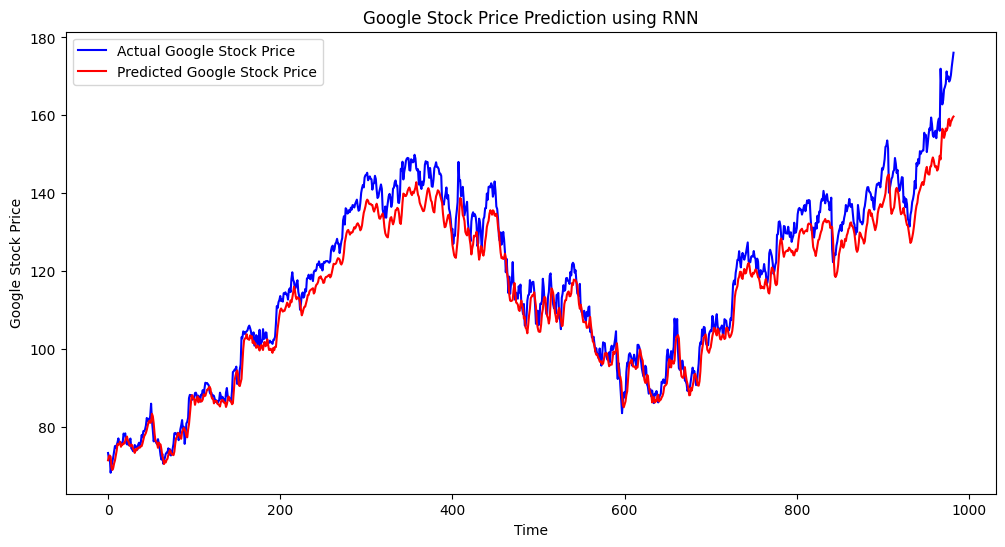

In [ ]:
# Plot Results
plt.figure(figsize=(12,6))

plt.plot(real_prices, color='blue', label='Actual Google Stock Price')

plt.plot(predicted_prices, color='red', label='Predicted Google Stock Price')

plt.title('Google Stock Price Prediction using RNN')

plt.xlabel('Time')

plt.ylabel('Google Stock Price')

plt.legend()

plt.show()